## Proyecto Final SIC (**Proyecto Aegis Vision:** Filtro Biométrico De Seguridad Para Protección De Menores)
---------------
### Equipo Umizoomi:
- Durán Rendón Santiago.
---------------
- **Objetivo:** Crear un verificador de edad basado en IA que actúe como filtro de seguridad para restringir el registro y el acceso de menores a funciones o contenidos no autorizados (funcionando como una especie de control parental avanzado).

#### Importación De Data Set DF

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load.
file_path = "ageutk_full.csv"

# Load the latest version.
df_UTK = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "roshan81/ageutk",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records: \n", df_UTK.head())

c:\Users\santi\OneDrive\Documentos\Santiago\Programacion\Samsung\Proyecto_Final\.envs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\santi\AppData\Local\Temp\ipykernel_15028\2322428699.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_UTK = kagglehub.load_dataset(


First 5 records: 
                                    files  age  gender
0  26_0_2_20170104023102422.jpg.chip.jpg   26       0
1  22_1_1_20170112233644761.jpg.chip.jpg   22       1
2  21_1_3_20170105003215901.jpg.chip.jpg   21       1
3  28_0_0_20170117180555824.jpg.chip.jpg   28       0
4  17_1_4_20170103222931966.jpg.chip.jpg   17       1


#### Importación De Bibliotecas Del Proyecto

In [2]:
# Manejo De Data.
import numpy as np
import pandas as pd

# Visualización.
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning.
from sklearn.model_selection import train_test_split

# Redes Neuronales.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

### Limpiando Data

In [3]:
# Tamaño Del Data Frame.
print("---------------------------------------")
tamano_AGE_UTK = df_UTK.shape
print("Tamaño del data set AGE-UTK:\n", tamano_AGE_UTK)
print("---------------------------------------")

# Información Del Data Frame.
print("\nInformación Del Data Frame:\n")
df_UTK.info()

# Nos Damos Cuenta Que Todas Las Filas Y Columnas Estan Llenas (Non-Null).

---------------------------------------
Tamaño del data set AGE-UTK:
 (23168, 3)
---------------------------------------

Información Del Data Frame:

<class 'pandas.DataFrame'>
RangeIndex: 23168 entries, 0 to 23167
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   files   23168 non-null  str  
 1   age     23168 non-null  int64
 2   gender  23168 non-null  int64
dtypes: int64(2), str(1)
memory usage: 543.1 KB


### Dividir La Información (Set De Entrenamiento 70% / Set De Validación 15% / Set De Pruebas 15%)

In [4]:
# Primera Separación Del DF. 
df_train, df_temp = train_test_split(df_UTK, test_size=0.3, random_state=1234)

#Segunda Separación del DF.
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=1234)

# Número De Imágenes.
print(f"Total de imágenes: {len(df_UTK['files'])}")
print(f"Imágenes para entrenar (df_train): {len(df_train)}")
print(f"Imágenes para probar (df_test): {len(df_test)}")
print(f"Imágenes para validar (df_val): {len(df_val)}")

Total de imágenes: 23168
Imágenes para entrenar (df_train): 16217
Imágenes para probar (df_test): 3476
Imágenes para validar (df_val): 3475


### Normalizar Los Pixeles De Las Imágenes Y Generadores

In [5]:
# Motor Para Normalizar (0 a 1).
generador_base = ImageDataGenerator(rescale=1./255.)

# Set De Entrenamiento.
train_generator = generador_base.flow_from_dataframe(
    dataframe = df_train,
    directory = r"C:/Users/santi/OneDrive/Documentos/Santiago/Programacion/Samsung/Proyecto_Final/Imagenes_Data_Set/UTKFace/UTKFace/UTKFace", # Directorio imágenes.
    x_col = 'files',
    y_col = 'age',
    target_size = (128, 128), # Pasamos todas las fotos a 128x128 píxeles.
    batch_size = 32,          # Leer de 32 en 32 para que no explote colab. 
    class_mode = 'raw',       # 'raw' preddecimos número exacto en regresión.
    shuffle = True,
    horizontal_flip = True,   # Voltear imágen efecto espejo.
    zoom_range = 0.1          # Zoom in y out de 0.1.
    )

Found 16217 validated image filenames.


In [6]:
# Set Para Probar.
test_generator = generador_base.flow_from_dataframe(
    dataframe = df_test,
    directory = r"C:/Users/santi/OneDrive/Documentos/Santiago/Programacion/Samsung/Proyecto_Final/Imagenes_Data_Set/UTKFace/UTKFace/UTKFace", # Directorio imágenes.
    x_col = 'files',
    y_col = 'age',
    target_size = (128, 128), # Pasamos todas las fotos a 128x128 píxeles.
    batch_size = 32,          # Leer de 32 en 32 para que no explote colab. 
    class_mode = 'raw',       # 'raw' preddecimos número exacto en regresión.
    shuffle = True
    )

Found 3476 validated image filenames.


In [7]:
# Set De Validación.
val_generator = generador_base.flow_from_dataframe(
    dataframe = df_val,
    directory = r"C:/Users/santi/OneDrive/Documentos/Santiago/Programacion/Samsung/Proyecto_Final/Imagenes_Data_Set/UTKFace/UTKFace/UTKFace", # Directorio imágenes.
    x_col = 'files',
    y_col = 'age',
    target_size = (128, 128), # Pasamos todas las fotos a 128x128 píxeles.
    batch_size = 32,          # Leer de 32 en 32 para que no explote colab. 
    class_mode = 'raw',        # 'raw' preddecimos número exacto en regresión.
    shuffle = False
    )

Found 3475 validated image filenames.


### Creando La Red Neuronal (CNN)

#### Bloques Convolucionales.

In [ ]:
my_model = Sequential() # Correr cada vez que queramos volver a correr los bloques convolucionales y entrenar un modelo.

# BLOQUE 1:
# Capa De Convolución 1.
my_model.add(Conv2D(
    filters=32, kernel_size=(3, 3), # Escane en bloques de 3x3 píxeles, no ponemos strides ya que el automático es de (1, 1), no ponemos data_format ya que el automático es de channels_last(Alto, Ancho, Colores).
    padding='same', # Agrega marcos falsos (ceros) a la imagen, por tanto la imagen no se encoge y entra y sale de 128x128.
    activation='relu', input_shape=(128, 128, 3), name='lupita_1', 
))
# Capa De Compresor 1.
my_model.add(MaxPooling2D(pool_size=(2, 2), # El estandar.
                          name='Compresor_1'))

# BLOQUE 2:
# Capa De Convolución 2.
my_model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', name='lupita_2', ))
# Capa De Compresor 2.
my_model.add(MaxPooling2D(pool_size=(2, 2), name='Compresor_2'))

# BLOQUE 3:
# Capa De Convolución 3.
my_model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu', name='lupita_3', ))
# Capa De Compresor 3.
my_model.add(MaxPooling2D(pool_size=(2, 2), name='Compresor_3'))

# Aplanar Imagen.
my_model.add(Flatten())

# Capa Densa.
my_model.add(Dense(units=128, name='FC_1', activation='relu')) # Capa oculta de 128 neuronas.

# Capa DropOut de 30%.
my_model.add(Dropout(0.3))

#Capa Densa Salida.
my_model.add(Dense(units=1, name='FC_2', activation='linear'))

c:\Users\santi\OneDrive\Documentos\Santiago\Programacion\Samsung\Proyecto_Final\.envs\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Planos Arquitectoónicos.

In [19]:
my_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lupita_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compresor_1 (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lupita_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compresor_2 (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lupita_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compresor_3 (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC_1 (Dense)                    │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC_2 (Dense)                    │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

#### Compilar Red Neuronal.

In [20]:
my_model.compile(optimizer='Adam', loss='mse', # Error Cuadrático Medio.
                 metrics=['mae'] # Dira cuantos años se equivoca exactamente.
                 )

#### Guardar Y Entrenar Red Neuronal 1.

In [35]:
history = my_model.fit(train_generator, validation_data=val_generator, epochs=10) # Si no se pone shuffle el por defecto es True, pero ya lo acomodamos arriba.

Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 443s 854ms/step - loss: 276.9183 - mae: 12.7438 - val_loss: 178.2938 - val_mae: 10.7987
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 212s 418ms/step - loss: 142.6593 - mae: 9.0026 - val_loss: 108.1079 - val_mae: 7.8154
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 210s 414ms/step - loss: 107.6454 - mae: 7.7672 - val_loss: 100.2216 - val_mae: 7.6167
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 236s 464ms/step - loss: 92.1532 - mae: 7.1522 - val_loss: 84.9905 - val_mae: 6.9270
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 211s 415ms/step - loss: 78.7209 - mae: 6.6118 - val_loss: 120.0395 - val_mae: 7.9685
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 238s 470ms/step - loss: 69.5607 - mae: 6.2011 - val_loss: 83.1612 - val_mae: 6.5819
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 220s 434ms/step - loss: 62.7160 - mae: 5.8985 - val_loss: 76.8743 - val_mae: 6.6678
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 228s 450ms/step - loss: 54.5059 - mae: 5.5092 - val_loss: 72.4856 - val_mae: 6.3221

#### Gráfica De Entrenamiento 1.

In [ ]:
# Curva De Aprendizaje.
hist = history.history
X_arr = np.arange(len(hist['loss']))+1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(X_arr, hist['loss'], '-o', label='Train Loss')
ax.plot(X_arr, hist['val_loss'], '--<', label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(X_arr, hist['mae'], '-o', label='Train mae')
ax.plot(X_arr, hist['val_mae'], '--<', label='Validation mae')
ax.set_xlabel('Epoch')
ax.set_ylabel('mae')
ax.legend(fontsize=15)

plt.show()

NameError: name 'history' is not defined

## Análisis De Nuestro Primer Entrenamiento Con 10 Epoch.

<div align="center">
<img src="Imagenes_Markdown\Entrenamiento_1.png" width="900">
</div>

------------------------
- Observando nuestras épocas: vemos que el val_mae es muy grande; por tanto, es posible que en una imagen de una persona que tenga 14 años y diga que tiene 20 años.
- Observando nuestras gráficas: vemos que a partir de la época 6 empieza a ser estable, por tanto, empieza a memorizar, empezando a tener overfitting.
------------------------

Para mejorar nuestro entrenamiento y evitar que memorice rotaremos las imagenes y haremos zoom (in y out) en los sets, así tambien agregaremos una capa densa de dropout apagando el 30% de las neuronas. 

#### Guardar Y Entrenar Red Neuronal v_2.

In [12]:
history_v2 = my_model.fit(train_generator, validation_data=val_generator, epochs=30)

Epoch 1/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 407s 798ms/step - loss: 254.6010 - mae: 12.1844 - val_loss: 148.5913 - val_mae: 9.1738
Epoch 2/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 209s 412ms/step - loss: 154.2562 - mae: 9.4382 - val_loss: 112.0154 - val_mae: 7.9323
Epoch 3/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 204s 403ms/step - loss: 124.7625 - mae: 8.3663 - val_loss: 120.7187 - val_mae: 8.6584
Epoch 4/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 209s 412ms/step - loss: 106.2682 - mae: 7.7182 - val_loss: 142.6247 - val_mae: 8.5388
Epoch 5/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 205s 403ms/step - loss: 96.4166 - mae: 7.3201 - val_loss: 86.6514 - val_mae: 6.8866
Epoch 6/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 206s 407ms/step - loss: 87.6559 - mae: 6.9853 - val_loss: 83.5249 - val_mae: 6.7508
Epoch 7/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 206s 406ms/step - loss: 79.9834 - mae: 6.6909 - val_loss: 84.2695 - val_mae: 6.9799
Epoch 8/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 206s 406ms/step - loss: 73.1956 - mae: 6.3850 - val_loss: 86.1913 - val_mae: 7.0931

#### Gráfica De Entrenamiento v_2.

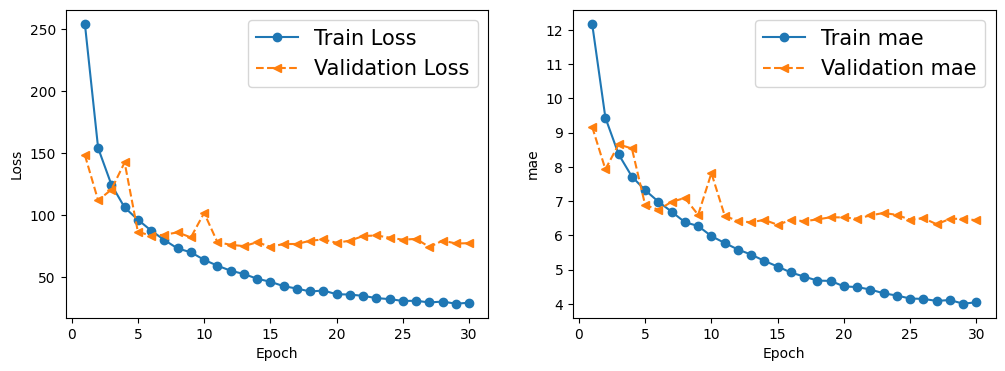

In [13]:
# Curva De Aprendizaje.
hist_v2 = history_v2.history
X_arr2 = np.arange(len(hist_v2['loss']))+1

fig = plt.figure(figsize=(12, 4))
ax2 = fig.add_subplot(1, 2, 1)
ax2.plot(X_arr2, hist_v2['loss'], '-o', label='Train Loss')
ax2.plot(X_arr2, hist_v2['val_loss'], '--<', label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=15)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(X_arr2, hist_v2['mae'], '-o', label='Train mae')
ax2.plot(X_arr2, hist_v2['val_mae'], '--<', label='Validation mae')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mae')
ax2.legend(fontsize=15)

plt.show()

## Análisis De Nuestro Segundo Entrenamiento Con 30 Epoch.

<div align="center">
<img src="Imagenes_Markdown\Entrenamiento_2.png" width="900">
</div>

------------------------
- Observando nuestras épocas: vemos que el val_mae es muy grande; por tanto, es posible que en una imagen de una persona que tenga 14 años y diga que tiene 20 años.
- Observando nuestras gráficas: vemos que a partir de la época 11 empieza a ser estable, por tanto, empieza a memorizar, empezando a tener overfitting, se separa más de la línea de Train mae de la línea de Validation mae lo cual es peor para nuestro modelo.
------------------------

Para mejorar nuestro entrenamiento hemos investigado más sobre keras, aprendiendo hacerca del "Early Stopping" Esto hace que el keras vigile nuestro val_mae y cuando empieza a detectar overfitting (no baja nuestro val_mae) detiene el entrenamiento.

#### EarlyStopping, Guardar Y Entrenar Red Neuronal v_3.

In [ ]:
# EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

freno = EarlyStopping(
    monitor = 'val_mae',           # Esto vigila nuestro val_mae.
    patience = 5,                # Si pasan 5 épocas sin que baje el val_mae se detiene.
    restore_best_weights = True  # Devuelve la mejor época, no la última y borra las 5 del patince.
)

In [22]:
history_v3 = my_model.fit(train_generator, validation_data=val_generator, epochs=50, # Sin miedo al éxito :)
                          callbacks = [freno])

Epoch 1/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 274s 535ms/step - loss: 284.1951 - mae: 12.9179 - val_loss: 162.0369 - val_mae: 9.9952
Epoch 2/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 183s 360ms/step - loss: 167.7852 - mae: 9.8857 - val_loss: 122.9551 - val_mae: 8.5182
Epoch 3/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 184s 362ms/step - loss: 131.5841 - mae: 8.6577 - val_loss: 100.9539 - val_mae: 7.3926
Epoch 4/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 227s 449ms/step - loss: 111.3466 - mae: 7.9085 - val_loss: 88.7680 - val_mae: 6.9663
Epoch 5/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 221s 436ms/step - loss: 99.9483 - mae: 7.4883 - val_loss: 84.8465 - val_mae: 6.8179
Epoch 6/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 183s 360ms/step - loss: 90.7360 - mae: 7.1099 - val_loss: 75.8067 - val_mae: 6.5246
Epoch 7/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 176s 348ms/step - loss: 86.3975 - mae: 6.9470 - val_loss: 77.0885 - val_mae: 6.4953
Epoch 8/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 181s 356ms/step - loss: 80.1776 - mae: 6.6711 - val_loss: 80.8211 - val_mae: 6.5303


#### Gráfica De Entrenamiento v_3.

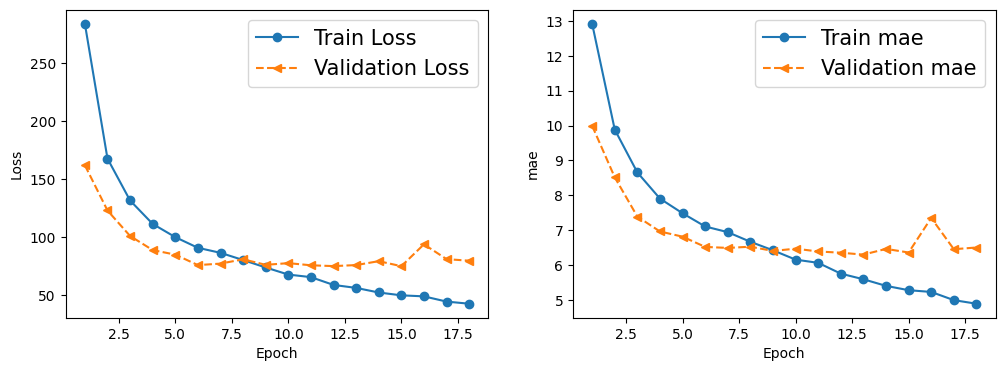

In [23]:
# Curva De Aprendizaje.
hist_v3 = history_v3.history
X_arr3 = np.arange(len(hist_v3['loss']))+1

fig = plt.figure(figsize=(12, 4))
ax3 = fig.add_subplot(1, 2, 1)
ax3.plot(X_arr3, hist_v3['loss'], '-o', label='Train Loss')
ax3.plot(X_arr3, hist_v3['val_loss'], '--<', label='Validation Loss')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.legend(fontsize=15)

ax3 = fig.add_subplot(1, 2, 2)
ax3.plot(X_arr3, hist_v3['mae'], '-o', label='Train mae')
ax3.plot(X_arr3, hist_v3['val_mae'], '--<', label='Validation mae')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('mae')
ax3.legend(fontsize=15)

plt.show()

## Test

In [24]:
test_results = my_model.evaluate(test_generator)

print(f"\n Error Absoluto Medio en años de equivocación reales: {test_results[1]:.2f}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 49s 447ms/step - loss: 83.3186 - mae: 6.6536

 Error Absoluto Medio en años de equivocación reales: 6.65


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


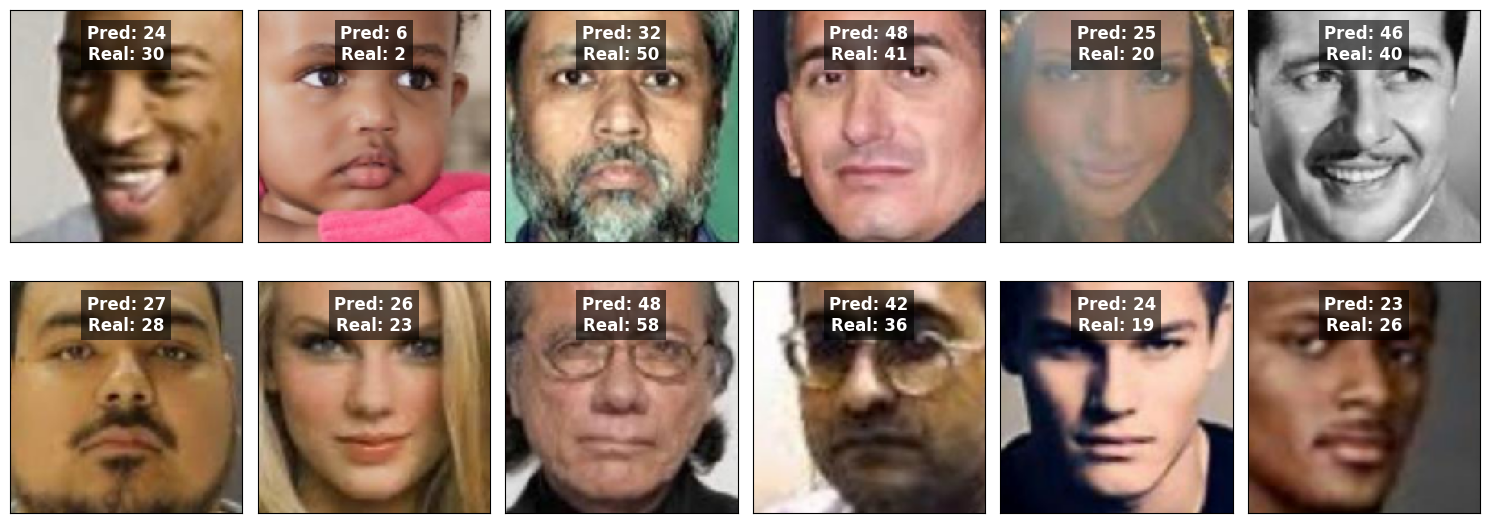

In [31]:
# Extraer Un Lote.
batch_test = next(test_generator) # Da un lote de 32 (batch_size=32) imágenes y sus respuestas correctas.
imagenes = batch_test[0] 
edades_reales = batch_test[1]

# Predicciones.
preds = my_model.predict(imagenes)

# Imprimir imágenes.
fig = plt.figure(figsize=(15, 6))
for i in range(12):
    ax = fig.add_subplot(2, 6, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    img = imagenes[i]
    ax.imshow(img)

    edad_predicha = int(np.round(preds[i][0]))
    edad_real = int(edades_reales[i])

    texto = f"Pred: {edad_predicha}\nReal: {edad_real}"
    ax.text(0.5, 0.85, texto,
            size=12, color='white', weight='bold',
            horizontalalignment='center',
            verticalalignment='center',
            transform=ax.transAxes,
            bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.show()

## Guardar El Modelo.

In [32]:
import os

if not os.path.exists('models'):
    os.mkdir('models')

my_model.save('models/history_v3.h5')

print('Modelo Guardado Exitosamente En Computadora.')

Modelo Guardado Exitosamente En Computadora.
